In [1]:
!python --version

Python 3.14.3


In [ ]:
from datasets import load_dataset
import pandas as pd
from huggingface_hub import HfFileSystem
import json

fs = HfFileSystem()

reviews = []

with fs.open("datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/Electronics.jsonl", "r") as f:
    for i, line in enumerate(f):
        if i >= 100:
            break
        reviews.append(json.loads(line))

reviews_df = pd.DataFrame(reviews)
reviews_df

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True
...,...,...,...,...,...,...,...,...,...,...
95,5.0,16g cork usb,it worked fine / great conversation piece too!,[],B018S7DPU8,B018S7DPU8,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1538613893334,0,True
96,5.0,Five Stars,perfect item for a novices user as I am. . .,[],B00MYU0E0K,B00MYU0E0K,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1533024545470,0,True
97,5.0,Five Stars,Great hard drive for the price! Installed with...,[],B000Q85WOK,B000Q85WOK,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1532072088895,0,True
98,5.0,Five Stars,Great little device!,[],B01KWY71BO,B01KWY71BO,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1532071758130,0,True


In [6]:
reviews_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


In [9]:
Items_to_print = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

print(reviews_df.head(10))

   rating                                        title                                               text                                             images        asin parent_asin                       user_id      timestamp  helpful_vote  verified_purchase
0     3.0            Smells like gasoline! Going back!  First & most offensive: they reek of gasoline ...  [{'small_image_url': 'https://m.media-amazon.c...  B083NRGZMM  B083NRGZMM  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1658185117948             0               True
1     1.0      Didn’t work at all lenses loose/broken.  These didn’t work. Idk if they were damaged in...                                                 []  B07N69T6TM  B07N69T6TM  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1592678549731             0               True
2     5.0                                   Excellent!  I love these. They even come with a carry case...                                                 []  B01G8JO5F2  B01G8JO5F2  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  15230930175

In [11]:
metadata = []

with fs.open("datasets/McAuley-Lab/Amazon-Reviews-2023/raw/meta_categories/meta_Electronics.jsonl", "r") as f:
    for i, meta in enumerate(f):
        if i >= 100:
            break
        metadata.append(json.loads(meta))
item_metadata_df = pd.DataFrame(metadata)
item_metadata_df

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Fat Shark,"[Electronics, Television & Video, Video Glasses]","{'Date First Available': 'August 2, 2014', 'Ma...",B00MCW7G9M,None
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SIIG,"[Electronics, Television & Video, Accessories,...",{'Product Dimensions': '0.83 x 4.17 x 2.05 inc...,B00YT6XQSE,None
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'AL 2Sides Video', 'url': 'https://...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Digi-Tatoo', 'Color': 'Fresh Marble...",B07SM135LS,None
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{'Date First Available': 'May 29, 2020', 'Manu...",B089CNGZCW,None
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Verizon,"[Electronics, Computers & Accessories, Compute...",{'Product Dimensions': '11.6 x 6.9 x 3.1 inche...,B004E2Z88O,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,All Electronics,LaCie Rugged All-Terrain Safe 500 GB USB 2.0/F...,3.2,18,"[Biometric authentication: up to ten users, 12...","[Product Description, The LaCie Rugged Safe is...",146.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],LaCie,"[Electronics, Computers & Accessories, Data St...","{'Product Dimensions': '5.7 x 3.5 x 1 inches',...",B003XT6OTG,None
96,Car Electronics,SSV Works Polaris Ranger XP9 900 2012-up and F...,5.0,1,[New],"[Fitment: (2015+) Polaris Ranger, (2013+) Rang...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SSV Works,"[Electronics, Car & Vehicle Electronics, Car E...","{'Item Weight': '5 pounds', 'Package Dimension...",B00O2IZZC4,None
97,Industrial & Scientific,"Monsoon G1/4"" to 1/2"" ID, 3/4"" OD Chain Gun Co...",5.0,1,[],[],25.71,[{'thumb': 'https://m.media-amazon.com/images/...,[],Monsoon,"[Electronics, Computers & Accessories, Compute...",{'Item Dimensions LxWxH': '3.94 x 1.97 x 1.97 ...,B00M9AEJQA,None
98,Camera & Photo,YEELE 6x4ft Galaxy Backdrop Purple Night Sky i...,4.8,19,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yeele,"[Electronics, Camera & Photo, Lighting & Studi...","{'Package Dimensions': '14 x 13 x 0.6 inches',...",B07XCWMSSY,None


In [12]:
print(item_metadata_df.head(10))

               main_category                                              title  average_rating  rating_number                                           features                                        description  price                                             images                                             videos            store                                         categories                                            details parent_asin bought_together
0            All Electronics             FS-1051 FATSHARK TELEPORTER V3 HEADSET             3.5              6                                                 []  [Teleporter V3 The “Teleporter V3” kit sets a ...    NaN  [{'thumb': 'https://m.media-amazon.com/images/...                                                 []        Fat Shark   [Electronics, Television & Video, Video Glasses]  {'Date First Available': 'August 2, 2014', 'Ma...  B00MCW7G9M            None
1            All Electronics                      Ce-H22B12-S1

In [13]:
import pandas as pd

item_metadata_df['price'] = pd.to_numeric(item_metadata_df['price'], errors='coerce')

none_price_products = item_metadata_df[item_metadata_df['price'].isna()][['title', 'price']]

valid_price_products = item_metadata_df[item_metadata_df['price'].notna()][['title', 'price']]

print(f'products with no valid price listed (total: {len(none_price_products)})')

for i, row in enumerate(none_price_products.itertuples(index=False), start = 1):
    print(f'{i}. {row.title} - Price: {row.price}')

print(f'producs with valid price listed (total: {len(valid_price_products)})')
for i, row in enumerate(valid_price_products.itertuples(index=False), start = 1):
    print(f'{i}. {row.title} - Price {row.price}')

products with no valid price listed (total: 56)
1. FS-1051 FATSHARK TELEPORTER V3 HEADSET - Price: nan
2. Ce-H22B12-S1 4Kx2K Hdmi 4Port - Price: nan
3. Raymarine Wi-Fish DownVision Blackbox Sonar with Wi-Fi - Price: nan
4. Protech iPhone 4 microscope 60X Lens with illumination Led - Price: nan
5. MOSISO Plastic Hard Shell Case & Keyboard Cover Compatible MacBook Air 11 Inch (Models: A1370 & A1465), Transparent Black - Price: nan
6. Network Magic 4.0 - Price: nan
7. Dock Audio Extender Adapter Converter Cable for iPod iPhone 4 4S iPhone 5 5S iPad, Samsung & Other Smart Phones - Price: nan
8. NANW Bands Compatible with Fitbit Versa/Versa 2/Versa Lite Small Large, Soft Silicone Replacement Band for Versa/Versa 2, Air Hole Wristband Strap for Women Men - Price: nan
9. eForCity Leather Case with Stand for 7-Inch Samsung Galaxy Tab 2, White/Black Zebra (PSAMGLXTLC26) - Price: nan
10. KEiiD PC Computer Speaker Compact Bluetooth Stereo System with Aluminum Housing for Laptop Desktop PC Gaming 

In [16]:
def get_product(product_title):
    try:
        price = item_metadata_df.loc[item_metadata_df['title'] == product_title, 'price'].values[0]
        if pd.isna(price):
            return 'no valid price listed'
    except IndexError:
        return 'product with title is not found'

In [15]:
known_title = "FS-1051 FATSHARK TELEPORTER V3 HEADSET"
print(f"\nPrice of '{known_title}': {get_product(known_title)}")


Price of 'FS-1051 FATSHARK TELEPORTER V3 HEADSET': no valid price listed


In [17]:
unknown_title = "Smart Phone Tripod Holder (Mobile Version)"
print(f"Price of '{unknown_title}': {get_product(unknown_title)}")

Price of 'Smart Phone Tripod Holder (Mobile Version)': product with title is not found


In [18]:
print("Reviews DataFrame columns:", reviews_df.columns)
print("-------------------")
print("Metadata DataFrame columns:", item_metadata_df.columns)

Reviews DataFrame columns: Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'], dtype='str')
-------------------
Metadata DataFrame columns: Index(['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together'], dtype='str')


In [20]:
print("Reviews DataFrame columns:")
for column in reviews_df.columns:
    print(f"- {column}")

print("-------------------")

print("Metadata DataFrame columns:")
for column in item_metadata_df.columns:
    print(f"- {column}")

Reviews DataFrame columns:
- rating
- title
- text
- images
- asin
- parent_asin
- user_id
- timestamp
- helpful_vote
- verified_purchase
-------------------
Metadata DataFrame columns:
- main_category
- title
- average_rating
- rating_number
- features
- description
- price
- images
- videos
- store
- categories
- details
- parent_asin
- bought_together


In [21]:

print("Reviews DataFrame columns and data types:")
print(reviews_df.dtypes)

print("-------------------")

print("Metadata DataFrame columns and data types:")
print(item_metadata_df.dtypes)

Reviews DataFrame columns and data types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
-------------------
Metadata DataFrame columns and data types:
main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store                  str
categories          object
details             object
parent_asin            str
bought_together     object
dtype: object


In [22]:

print("Reviews DataFrame columns and data types:")
for column in reviews_df.columns:
    print(f"- {column}: {reviews_df[column].dtype}")

print("-------------------")

print("Metadata DataFrame columns and data types:")
for column in item_metadata_df.columns:
    print(f"- {column}: {item_metadata_df[column].dtype}")

Reviews DataFrame columns and data types:
- rating: float64
- title: str
- text: str
- images: object
- asin: str
- parent_asin: str
- user_id: str
- timestamp: int64
- helpful_vote: int64
- verified_purchase: bool
-------------------
Metadata DataFrame columns and data types:
- main_category: str
- title: str
- average_rating: float64
- rating_number: int64
- features: object
- description: object
- price: float64
- images: object
- videos: object
- store: str
- categories: object
- details: object
- parent_asin: str
- bought_together: object


In [24]:

print("Reviews DataFrame info:")
print(reviews_df.info())

print("-------------------")

print("Metadata DataFrame info:")
print(item_metadata_df.info())

Reviews DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    str    
 2   text               100 non-null    str    
 3   images             100 non-null    object 
 4   asin               100 non-null    str    
 5   parent_asin        100 non-null    str    
 6   user_id            100 non-null    str    
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(1), str(5)
memory usage: 32.0+ KB
None
-------------------
Metadata DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  

In [26]:
# Select relevant columns
item_metadata_cleaned_df = item_metadata_df[['title', 'average_rating', 'price']]
average_rating_filter = 4.5

# Convert the price column to numeric, setting errors='coerce' to handle non-numeric values
item_metadata_cleaned_df.loc[:, 'price'] = pd.to_numeric(item_metadata_cleaned_df['price'], errors='coerce')

# Filter to get only products with average rating set to the filter, valid price, and non-null title
top_products_df = item_metadata_cleaned_df[
    (item_metadata_cleaned_df['average_rating'] >= average_rating_filter) &
    (item_metadata_cleaned_df['price'].notna()) &
    (item_metadata_cleaned_df['title'].notna())
]

# Print the new cleaned DataFrame
top_products_df

,title,average_rating,price
2,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,19.99
3,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,9.99
14,Novelty Cute Cartoon USB 2.0 Flash Drive Data ...,4.7,8.98
16,ANNKE 4K 16CH Security DVR Recorder with Human...,5.0,909.99
17,BIPRA U3 2.5 inch USB 3.0 NTFS Portable Extern...,5.0,98.49
19,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,3.99
24,Polaroid Originals Now Viewfinder i-Type Insta...,4.8,179.99
30,HP Elitebook 8560W New Replacement LCD Screen ...,4.7,63.33
33,May Chen Compatible with MacBook Pro 16 inch C...,4.5,26.99
37,Wenlaty Case Compatible with iPad 9th /8th /7t...,4.7,19.99


In [27]:
# Review the items of the original dataframe
num_items_original = item_metadata_df.shape[0]
print(f"Number of items in the original DataFrame: {num_items_original}")

# Review the new items in cleaned dataframe
num_items_cleaned = top_products_df.shape[0]
print(f"Number of items in the cleaned DataFrame: {num_items_cleaned}")

Number of items in the original DataFrame: 100
Number of items in the cleaned DataFrame: 21


In [28]:
part = float(input("Enter the number of items in the cleaned DataFrame: "))
whole = float(input("Enter the number of items in the original DataFrame: "))

# Function to calculate percentage
def calculate_percentage(part, whole):
    if whole == 0:
        raise ValueError("The whole value cannot be zero.")

    # Calculate the percentage
    percentage = part / whole * 100
    return percentage

# Calculate and print the percentage
try:
    result = calculate_percentage(part, whole)
    print(f"{part} is {result:.2f}% of {whole}")
except ValueError as e:
    print(e)

21.0 is 21.00% of 100.0


In [29]:
# Save the DataFrame as a CSV file
top_products_df.to_csv('top_products.csv', index=False)

# Verify that the file is saved
!ls -lh top_products.csv

-rw-r--r--@ 1 abhishekbarve  staff   3.2K Apr 11 17:03 top_products.csv


In [30]:
# Save the DataFrame as a Parquet file
top_products_df.to_parquet('top_products.parquet', index=False)

# Verify that the file is saved
!ls -lh top_products.parquet

-rw-r--r--@ 1 abhishekbarve  staff   5.3K Apr 11 17:04 top_products.parquet


In [36]:
# Initialize an empty list to collect top-rated product titles
top_rated_titles = []

# Create a for loop to iterate over the highly_rated_products_df DataFrame
# Use the `append` method for the titles to add them to the `top_rated_titles` list
for index, product in top_products_df.iterrows():
    top_rated_titles.append(product['title'])

# Print the list of top-rated product titles
print("List of Top-Rated Product Titles:")
print(top_rated_titles)

List of Top-Rated Product Titles:
['Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]', 'NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband', 'Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)', 'ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive', 'BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB)', 'Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for Teens Girls Adults Kids,Laptop Car Cup Computer Guitar Skateboard Lug

In [37]:
for i, title in enumerate(top_rated_titles, start=1):
    print(f"{i}. {title}")

1. Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]
2. NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband
3. Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)
4. ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive
5. BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB)
6. Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for Teens Girls Adults Kids,Laptop Car Cup Computer Guitar Skateboard Luggage Phone Aesthetic Stickers Pac

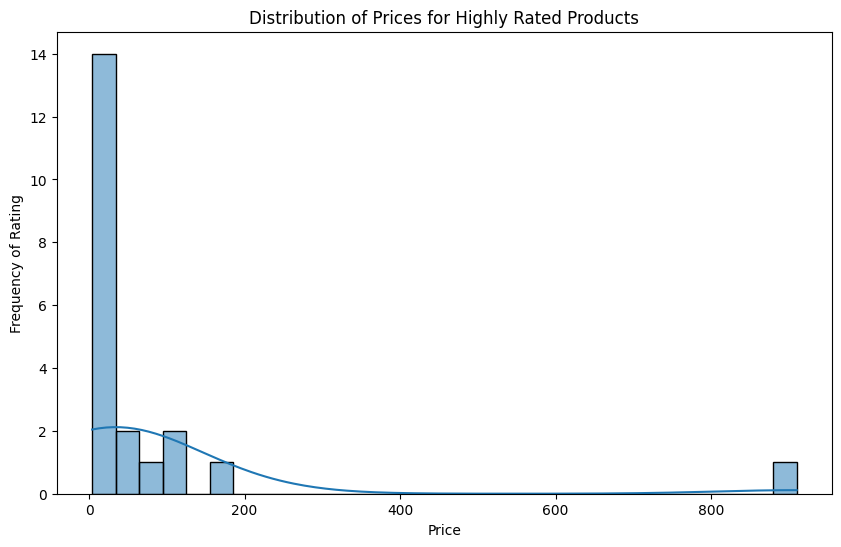

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Prices
plt.figure(figsize=(10, 6))
sns.histplot(
    top_products_df['price'],
    bins=30,
    kde=True,
)
plt.title('Distribution of Prices for Highly Rated Products')
plt.xlabel('Price')
plt.ylabel('Frequency of Rating')
plt.show()

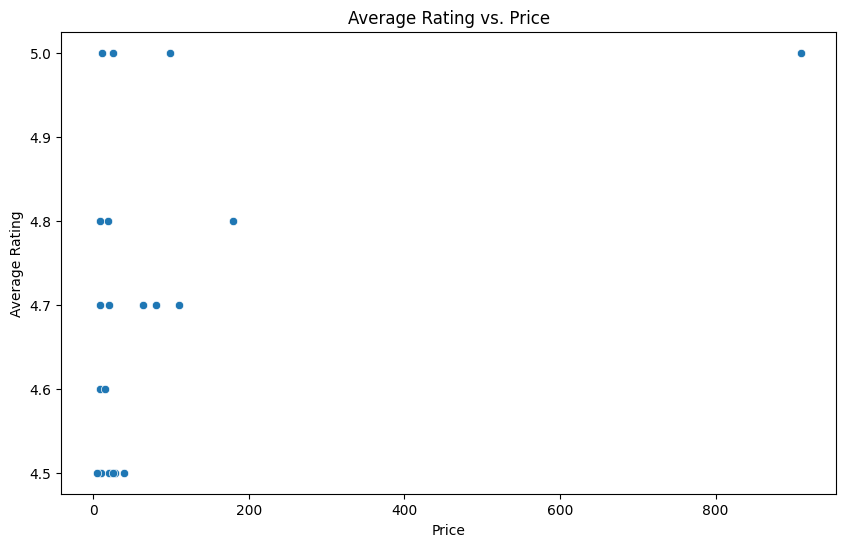

In [39]:
# Average Rating vs. Price
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=top_products_df, 
    x='price', 
    y='average_rating'
)
plt.title('Average Rating vs. Price')
plt.xlabel('Price')
plt.ylabel('Average Rating')
plt.show()

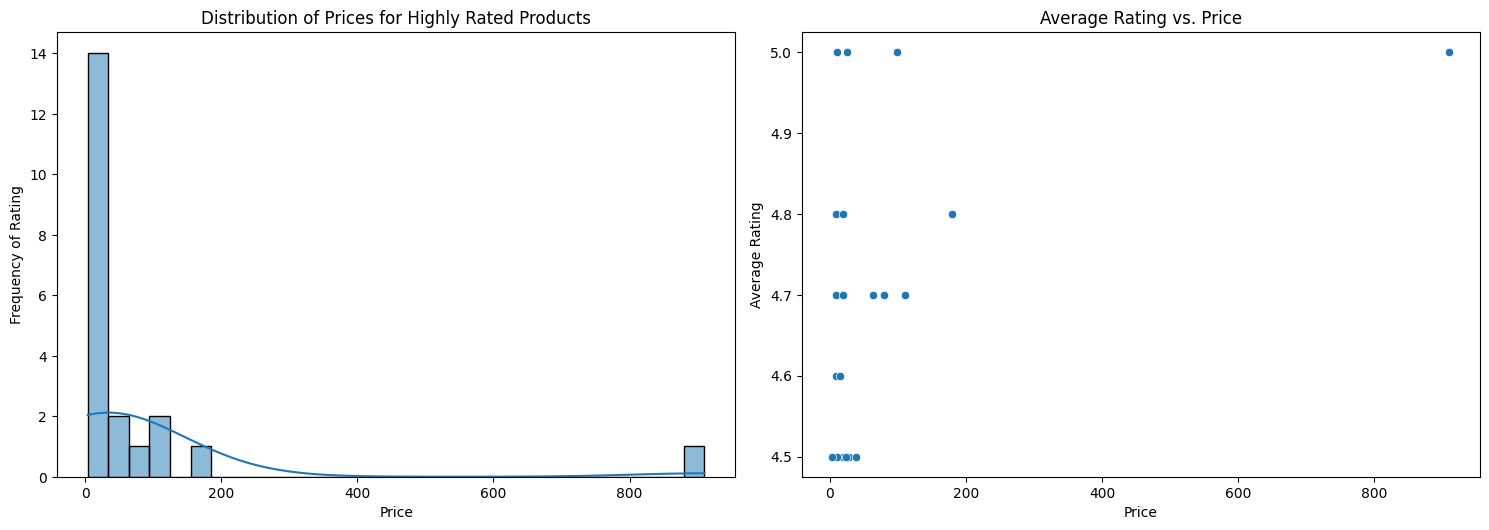

In [40]:
# Create a Dashboard Layout
plt.figure(figsize=(15, 10))

# Subplot 1: Distribution of Prices
plt.subplot(2, 2, 1)
sns.histplot(top_products_df['price'], bins=30, kde=True)
plt.title('Distribution of Prices for Highly Rated Products')
plt.xlabel('Price')
plt.ylabel('Frequency of Rating')

# Subplot 2: Average Rating vs. Price
plt.subplot(2, 2, 2)
sns.scatterplot(data=top_products_df, x='price', y='average_rating')
plt.title('Average Rating vs. Price')
plt.xlabel('Price')
plt.ylabel('Average Rating')

# Show the Dashboard
plt.tight_layout()
plt.show()

In [41]:
agerage_rating_cutoff = 4.7
highly_rated_products_df = top_products_df[top_products_df['average_rating'] >= agerage_rating_cutoff]

print(highly_rated_products_df)

                                                title  average_rating   price
14  Novelty Cute Cartoon USB 2.0 Flash Drive Data ...             4.7    8.98
16  ANNKE 4K 16CH Security DVR Recorder with Human...             5.0  909.99
17  BIPRA U3 2.5 inch USB 3.0 NTFS Portable Extern...             5.0   98.49
24  Polaroid Originals Now Viewfinder i-Type Insta...             4.8  179.99
30  HP Elitebook 8560W New Replacement LCD Screen ...             4.7   63.33
37  Wenlaty Case Compatible with iPad 9th /8th /7t...             4.7   19.99
42  Centon Electronics Flash Memory Card (S1-SDHU1...             4.8    8.99
46  PNY 1TB PRO Elite Class 10 U3 V30 microSDXC Fl...             4.7  109.99
50  JBL FLIP 5 - Waterproof Portable Bluetooth Spe...             4.7   79.90
60  MHYALUDO Silicone Print Case Cover for Apple A...             5.0   10.99
78  CoBak Case for Kindle Paperwhite - All New PU ...             4.8   18.95
97  Monsoon G1/4" to 1/2" ID, 3/4" OD Chain Gun Co...           

In [44]:
highly_rated_num_items = highly_rated_products_df.shape[0]
print(highly_rated_num_items)

12


In [45]:
top_products_df.shape[0]

21

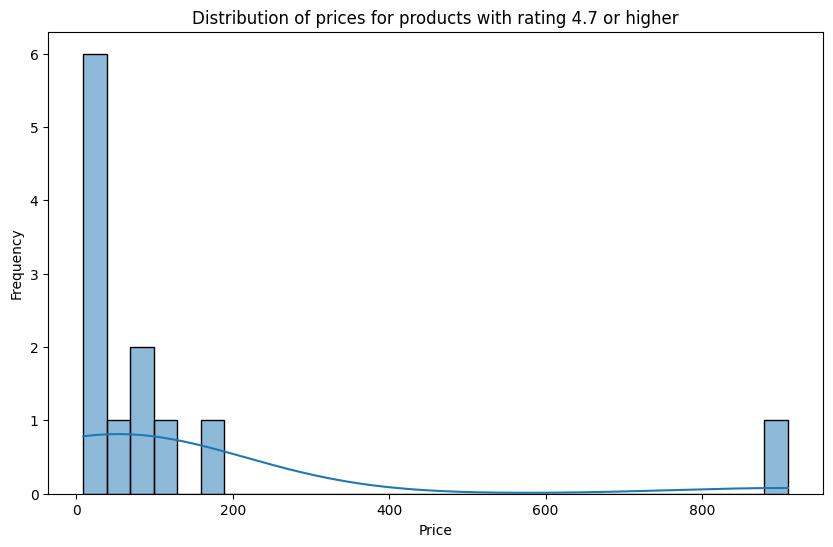

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(highly_rated_products_df['price'], bins=30, kde=True)

plt.title('Distribution of prices for products with rating 4.7 or higher')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

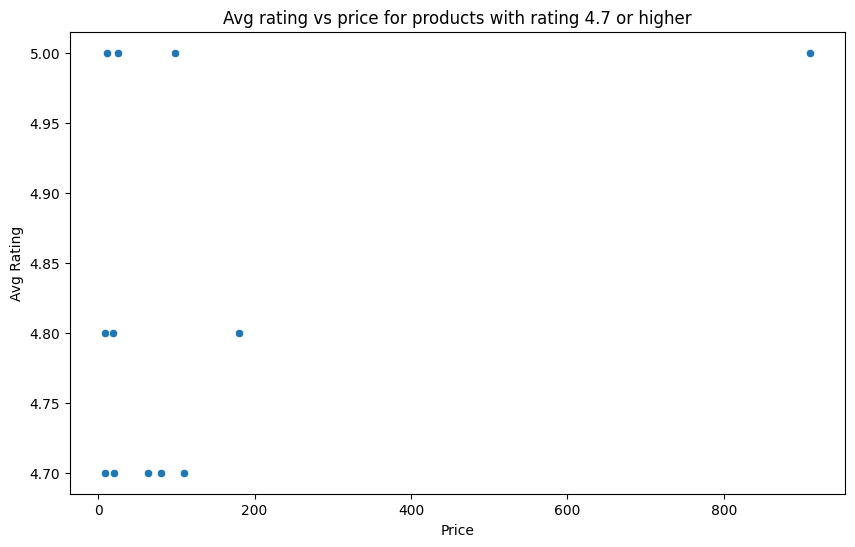

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=highly_rated_products_df, x='price', y='average_rating')
plt.title('Avg rating vs price for products with rating 4.7 or higher')
plt.xlabel('Price')
plt.ylabel('Avg Rating')
plt.show()

,title,average_rating,price
16,ANNKE 4K 16CH Security DVR Recorder with Human...,5.0,909.99
17,BIPRA U3 2.5 inch USB 3.0 NTFS Portable Extern...,5.0,98.49
60,MHYALUDO Silicone Print Case Cover for Apple A...,5.0,10.99
97,"Monsoon G1/4"" to 1/2"" ID, 3/4"" OD Chain Gun Co...",5.0,25.71
24,Polaroid Originals Now Viewfinder i-Type Insta...,4.8,179.99
42,Centon Electronics Flash Memory Card (S1-SDHU1...,4.8,8.99
78,CoBak Case for Kindle Paperwhite - All New PU ...,4.8,18.95
14,Novelty Cute Cartoon USB 2.0 Flash Drive Data ...,4.7,8.98
30,HP Elitebook 8560W New Replacement LCD Screen ...,4.7,63.33
37,Wenlaty Case Compatible with iPad 9th /8th /7t...,4.7,19.99


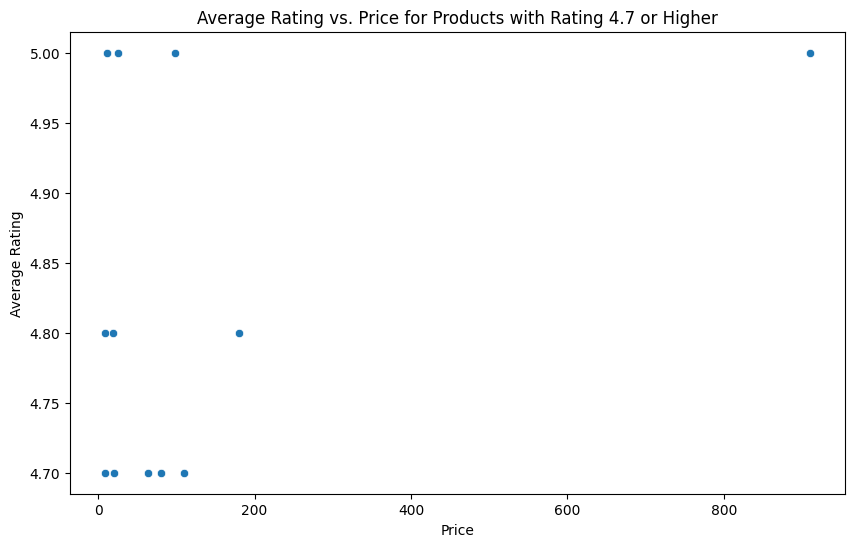

In [48]:
from IPython.display import display

highly_rated_products_df_cutoff = 4.7
highly_rated_products_df = top_products_df[top_products_df['average_rating'] >= highly_rated_products_df_cutoff]

highly_rated_products_df = highly_rated_products_df.sort_values(by='average_rating', ascending=False)

display(highly_rated_products_df)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=highly_rated_products_df, x='price', y='average_rating')
plt.title('Average Rating vs. Price for Products with Rating 4.7 or Higher')
plt.xlabel('Price')
plt.ylabel('Average Rating')
plt.show()